In [1]:
# Set gpu to run on 1
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1"
import tensorflow as tf
import gc
import pandas as pd

from Function_definitions import process_spectral_images, plot_function, evaluation_plot, prep_data_generator, rmse, process_predictions

2025-07-20 20:00:24.748810: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-20 20:00:24.803421: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-20 20:00:24.803465: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-20 20:00:24.805163: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-20 20:00:24.817468: I tensorflow/core/platform/cpu_feature_guar

In [2]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
# from detecto import core, utils, visualize
# from detecto.visualize import show_labeled_image, plot_prediction_grid
# from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
# import torch
import tensorflow as tf
from tensorflow.keras.models import load_model

np.random.seed(779)
tf.random.set_seed(779)



In [3]:
batch_size = 32


In [4]:
File_path = '/media/2tbdisk3/data/Haidee/Results/'


In [5]:
prediction_save_path = '/media/2tbdisk3/data/Haidee/Results/Predictions/'

<!-- ## Visualise model training history ## -->

In [6]:
# import pandas as pd

# Run 0 # Base
# run = 'run0'
# history_var3 = pd.read_csv(f'{File_path}/2025-05-18run0_everything_model50px - no_OneHotEncoding_history_var3_subset.csv')

##Run 1 # Each variable split
# img_size = 50
# run = 'run1'
# history_brix = pd.read_csv(f'{File_path}2025-05-20run1_50px_single_featurehistory_brix.csv')
# history_starch = pd.read_csv(f'{File_path}2025-05-20run1_50px_single_featurehistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-05-20run1_50px_single_feature_2025-05-20history_firmness.csv')

# # # #Run 2
# history_brix = pd.read_csv(f'{File_path}2025-05-20run2_30pxhistory_brix.csv')
# history_starch = pd.read_csv(f'{File_path}2025-05-20run2_30pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-05-20run2_30pxhistory_firmness.csv')

# # # Run 3
# history_brix = pd.read_csv(f'{File_path}2025-05-20run3_40pxhistory_brix.csv')
# history_starch = pd.read_csv(f'{File_path}2025-05-21run3_40pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-05-21run3_40pxhistory_firmness.csv')


# # # Run 4
# history_brix =     pd.read_csv(f'{File_path}2025-05-21run4_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-05-21run4_20pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-05-21run4_20pxhistory_firmness.csv')

# # Run 5
# history_brix =     pd.read_csv(f'{File_path}2025-05-21run5_40pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-05-21run5_40pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-05-21run5_40pxhistory_firmness.csv')

# # Run 6
# history_brix =     pd.read_csv(f'{File_path}2025-05-21run6_40px_SideAhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-05-21run6_40px_SideAhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-05-21run6_40px_SideAhistory_firmness.csv')

# # # Run 7
# history_brix =     pd.read_csv(f'{File_path}2025-05-26run7_40px_SideA_bays_opt_parametershistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-05-26run7_40px_SideA_bays_opt_parametershistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-05-26run7_40px_SideA_bays_opt_parametershistory_firmness.csv')


# # # # Run 8
# history_brix =     pd.read_csv(f'{File_path}2025-05-26run8_40px_bays_opt_parametershistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-05-26run8_40px_bays_opt_parametershistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-05-26run8_40px_bays_opt_parametershistory_firmness.csv')


# Run 9
history_brix =     pd.read_csv(f'{File_path}2025-05-27run_9DCNN_50px_history_brix_3dcnn.csv')
history_starch =   pd.read_csv(f'{File_path}2025-05-27run_9DCNN_50px_history_starch_3dcnn.csv')
history_firmness = pd.read_csv(f'{File_path}2025-05-27run_9DCNN_50px_history_firmness_3dcnn.csv')

# # Run 10
# history_brix =     pd.read_csv(f'{File_path}2025-04-12run10_bays_opt_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-12run10_bays_opt_20pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-12run10_bays_opt_20pxhistory_firmness.csv')

# # Run 11
# history_brix =     pd.read_csv(f'{File_path}2025-04-13run11_side_a_20pxhistory_brix.csv')
# history_starch =   pd.read_csv(f'{File_path}2025-04-13run11_side_a_20pxhistory_starch.csv')
# history_firmness = pd.read_csv(f'{File_path}2025-04-13run11_side_a_20pxhistory_firmness.csv')


In [20]:
# Create a function to generate plots

# def plot_function(history, feature, value):
#     if value == 'loss':
#         plt.plot(history['loss'], label='Train Loss')
#         plt.plot(history['val_loss'], label='Validation Loss')
#         plt.xlabel('Epochs')
#         plt.ylabel('Loss')
#         plt.title(f'{feature}: Training and Validation Loss Over Epochs')
#         plt.legend()
#         plt.show()
#     elif value == 'MAE':
#         plt.plot(history['mae'], label='Train MAE')
#         plt.plot(history['val_mae'], label='Validation MAE')
#         plt.xlabel('Epochs')
#         plt.ylabel('MAE')
#         plt.title(f'{feature}:Training and Validation MAE Over Epochs')
#         plt.legend()
#         plt.show()



In [21]:
# plot_function(history_var3,'All three variables', 'MAE')
# plot_function(history_var3,'All three variables', 'loss')

In [22]:
# 

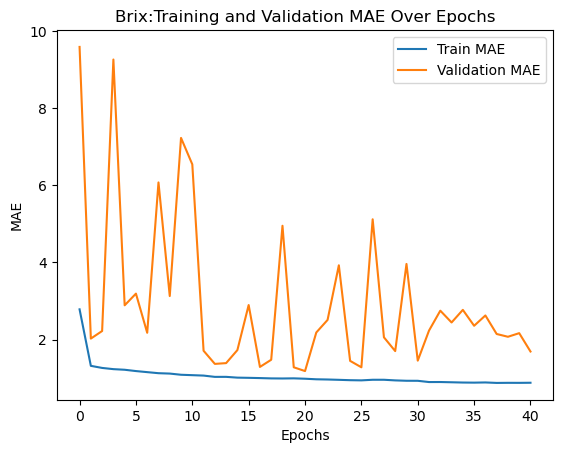

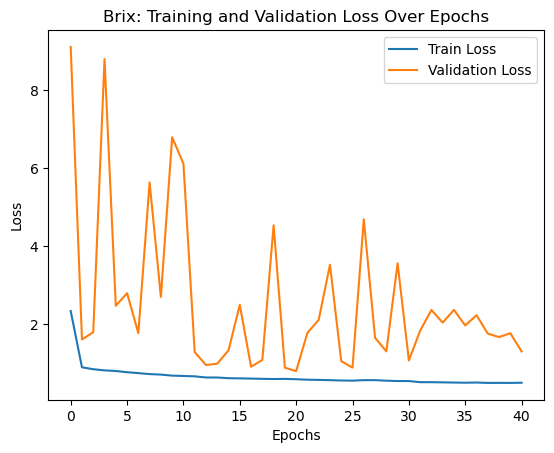

In [7]:
plot_function(history_brix, 'Brix', 'MAE')
plot_function(history_brix, 'Brix', 'loss')

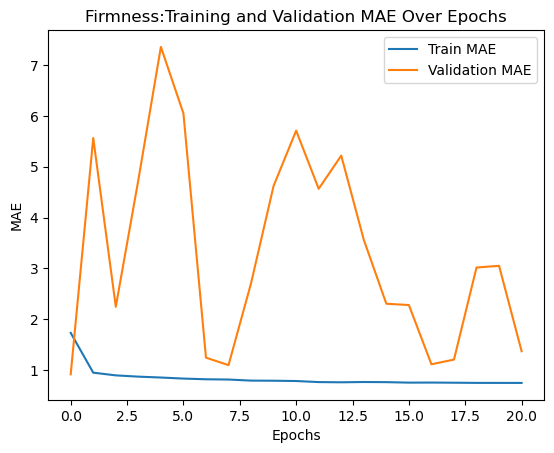

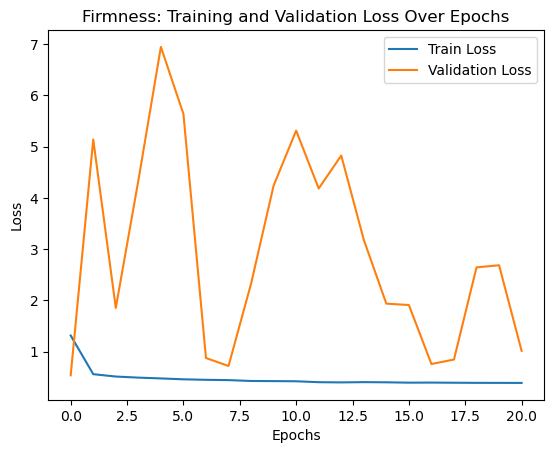

In [8]:
plot_function(history_firmness, 'Firmness', 'MAE')
plot_function(history_firmness, 'Firmness', 'loss')

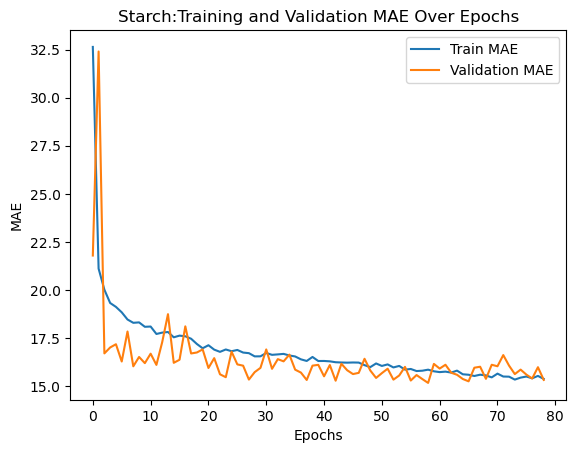

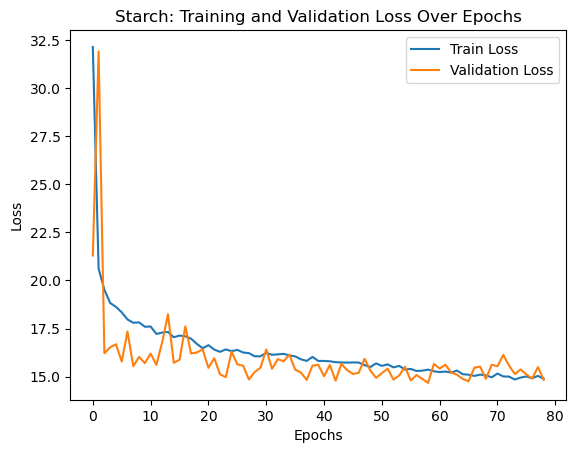

In [9]:
plot_function(history_starch, 'Starch', 'MAE')
plot_function(history_starch, 'Starch', 'loss')

## Models ##

In [6]:
# # load prediction models


## Run 0
# img_size = 50
# run_no = 'run0'
# one_hot_encoding = False
# prediction_model_var3 = tf.keras.models.load_model(f"{File_path}2025-05-18run0_everything_model50px - no_OneHotEncoding_model_file_var3.keras")


#Run1
# img_size = 50
# run_no = 'run1'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-20run1_50px_single_feature_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-20run1_50px_single_feature_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-20run1_50px_single_feature_2025-05-20_model_file_firmness.keras")


# # # Run2
# img_size = 30
# run_no = 'run2'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-20run2_30px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-20run2_30px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-20run2_30px_model_file_firmness.keras")


# # # Run3 
# img_size = 40
# run_no = 'run3'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-21run3_40px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-20run3_40px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-21run3_40px_model_file_firmness.keras")


# # # # Run4
# img_size = 20
# run_no = 'run4'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-21run4_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-21run4_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-21run4_20px_model_file_firmness.keras")

# # # Run 5
# img_size = 40
# run_no = 'run5'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-21run5_40px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-21run5_40px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-21run5_40px_model_file_firmness.keras")


# # Run 6
# img_size = 40
# run_no = 'run6'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-21run6_40px_SideA_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-21run6_40px_SideA_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-21run6_40px_SideA_model_file_firmness.keras")

# # Run 7 
# img_size = 40
# run_no = 'run7'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-26run8_40px_bays_opt_parameters_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-26run7_40px_SideA_bays_opt_parameters_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-26run7_40px_SideA_bays_opt_parameters_model_file_firmness.keras")


# # Run 8 
# img_size = 40
# run_no = 'run8'
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-26run8_40px_bays_opt_parameters_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-26run8_40px_bays_opt_parameters_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-26run8_40px_bays_opt_parameters_model_file_firmness.keras")

# # Run 9 3dCNN model
# img_size = 50
# run_no = 'run9'
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-05-27run_9DCNN_50px_model_file_brix_3dcnn.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-05-27run_9DCNN_50px_model_file_firmness_3dcnn.keras")
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-05-27run_9DCNN_50px_model_file_starch_3dcnn.keras")


# # # Run 10
# run_no = 'run10'
# img_size = 20
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-12run10_bays_opt_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-12run10_bays_opt_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-12run10_bays_opt_20px_model_file_firmness.keras")

# # Run 11
# run_no = 'run11'
# img_size = 20
# prediction_model_starch = tf.keras.models.load_model(f"{File_path}2025-04-13run11_side_a_20px_model_file_starch.keras")
# prediction_model_brix = tf.keras.models.load_model(f"{File_path}2025-04-13run11_side_a_20px_model_file_brix.keras")
# prediction_model_firmness = tf.keras.models.load_model(f"{File_path}2025-04-13run11_side_a_20px_model_file_firmness.keras")

# # # Run 28 3 var
prediction_model_var3 = tf.keras.models.load_model(f"/media/2tbdisk3/data/Haidee/Results/2025-07-20run_28_3var_40px_model_trained_vit_var3.keras")




2025-07-20 20:01:47.948984: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79086 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:65:00.0, compute capability: 8.0
2025-07-20 20:01:47.951477: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79086 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:ca:00.0, compute capability: 8.0


In [23]:
prediction_model_var3.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 40, 40, 210)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 8, 8, 128)            672128    ['input_1[0][0]']             
                                                                                                  
 reshape (Reshape)           (None, 64, 128)              0         ['conv2d[0][0]']              
                                                                                                  
 tf.__operators__.add (TFOp  (None, 64, 128)              0         ['reshape[0][0]']             
 Lambda)                                                                                      

In [7]:
img_size = 40

if img_size == 30 or img_size == 20:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'



# #Train data


# X_train_Firmness_train          = np.load(f'{training_data_save_path}X_train_all_years_Firmness_shuffled.npy')
Y_train_Firmness_train          = np.load(f'{training_data_save_path}Y_train_all_years_Firmness_shuffled.npy')
Firmness_encoder_shuffled  = np.load(f'{training_data_save_path}X_train_all_years_Firmness_encoder_shuffled.npy')
# X_train_Brix_train          = np.load(f'{training_data_save_path}X_train_all_years_Brix_shuffled.npy')
Y_train_Brix_train          = np.load(f'{training_data_save_path}Y_train_all_years_Brix_shuffled.npy')
Brix_encoder_shuffled  = np.load(f'{training_data_save_path}X_train_all_years_Brix_encoder_shuffled.npy')
X_train_Starch_train          = np.load(f'{training_data_save_path}X_train_all_years_Starch_shuffled.npy')
Y_train_Starch_train          = np.load(f'{training_data_save_path}Y_train_all_years_Starch_shuffled.npy')
Starch_encoder_shuffled  = np.load(f'{training_data_save_path}X_train_all_years_Starch_encoder_shuffled.npy')


# Test data
Y_test_all_years_Starch_shuffled = np.load(f'{training_data_save_path}Y_test_all_years_Starch_shuffled.npy')
X_test_all_years_Starch_shuffled = np.load(f'{training_data_save_path}X_test_all_years_Starch_shuffled.npy')
X_test_all_years_Starch_encoder = np.load(f'{training_data_save_path}X_test_all_years_Starch_encoder_shuffled.npy')
Y_test_all_years_Brix_shuffled = np.load(f'{training_data_save_path}Y_test_all_years_Brix_shuffled.npy')
# X_test_all_years_Brix_shuffled = np.load(f'{training_data_save_path}X_test_all_years_Brix_shuffled.npy')
# X_test_all_years_Brix_encoder = np.load(f'{training_data_save_path}X_test_all_years_Brix_encoder_shuffled.npy')
Y_test_all_years_Firmness_shuffled = np.load(f'{training_data_save_path}Y_test_all_years_Firmness_shuffled.npy')
# X_test_all_years_Firmness_shuffled = np.load(f'{training_data_save_path}X_test_all_years_Firmness_shuffled.npy')
# X_test_all_years_Firmness_encoder = np.load(f'{training_data_save_path}X_test_all_years_Firmness_encoder_shuffled.npy')



In [27]:
print(Y_train_Starch_train[0])

68.0


In [ ]:

# # Side A data
# if img_size == 30 or img_size == 20:
#     training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/'
# elif img_size == 50 or img_size ==40:
#     training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/'


# # X files are all the same between the different variables
# Y_train_Firmness_train          = np.load(f'{training_data_save_path}Side_A_Y_train_all_years_Firmness_shuffled.npy')
# Firmness_encoder_shuffled  = np.load(f'{training_data_save_path}Side_A_X_train_all_years_Firmness_encoder.npy')
# Y_train_Brix_train          = np.load(f'{training_data_save_path}Side_A_Y_train_all_years_Brix_shuffled.npy')
# Brix_encoder_shuffled  = np.load(f'{training_data_save_path}Side_A_X_train_all_years_Brix_encoder.npy')
# X_train_Starch_train          = np.load(f'{training_data_save_path}Side_A_X_train_all_years_Starch_shuffled.npy')
# Y_train_Starch_train          = np.load(f'{training_data_save_path}Side_A_Y_train_all_years_Starch_shuffled.npy')
# Starch_encoder_shuffled  = np.load(f'{training_data_save_path}Side_A_X_train_all_years_Starch_encoder.npy')


# # Test data
# Y_test_all_years_Starch_shuffled = np.load(f'{training_data_save_path}Side_A_Y_test_all_years_Starch_shuffled.npy')
# X_test_all_years_Starch_shuffled = np.load(f'{training_data_save_path}Side_A_X_test_all_years_Starch_shuffled.npy')
# X_test_all_years_Starch_encoder = np.load(f'{training_data_save_path}Side_A_X_test_all_years_Starch_encoder.npy')
# Y_test_all_years_Brix_shuffled = np.load(f'{training_data_save_path}Side_A_Y_test_all_years_Brix_shuffled.npy')
# Y_test_all_years_Firmness_shuffled = np.load(f'{training_data_save_path}Side_A_Y_test_all_years_Firmness_shuffled.npy')




In [28]:
# print(X_test_all_years_Starch_shuffled[:3])
# print(X_test_all_years_Starch_encoder[:3])


In [29]:
# print(prediction_model_brix.summary())
# print(prediction_model_firmness.summary())

In [30]:
# print(prediction_model_starch.summary())

In [12]:
# for var 3 data
import numpy as np

def prep_data(file_list, cultivars, img_size, batch_size, prediction_model):
    # Initialize lists to store the batch data
    batch_data = []
    batch_cultivars = []

    # Load the batch of data from file paths
    for i, file in enumerate(file_list):
        try:
            data = np.load(file)
            if img_size == 14:
                data_reduced = data[3:-3, 3:-3, :]
            elif img_size == 40:
                data_reduced = data[5:-5, 5:-5, :]
            else:
                data_reduced = data

            batch_data.append(data_reduced)
            batch_cultivars.append(cultivars[i])

            # Process in smaller batches
            if (i + 1) % batch_size == 0 or (i + 1) == len(file_list):
                # Convert lists to numpy arrays
                batch_data_np = np.array(batch_data, dtype=np.float32)
                batch_cultivars_np = np.array(batch_cultivars, dtype=np.float32)

                # Expand cultivar information to match the input data's spatial dimensions
                expanded_cultivars = np.repeat(batch_cultivars_np[:, np.newaxis, np.newaxis, :], img_size, axis=1)
                expanded_cultivars = np.repeat(expanded_cultivars, img_size, axis=2)

                # Concatenate cultivar information with the original data along the last axis
                combined_data = np.concatenate([batch_data_np, expanded_cultivars], axis=-1)

                # Use the combined data for predictions
                predictions = prediction_model.predict(combined_data)

                # Clear batch data to free up memory
                batch_data = []
                batch_cultivars = []

                # Return predictions for the current batch
                yield predictions

        except FileNotFoundError:
            print(f"File not found: {file}. Skipping...")
            continue

# Example usage
# predictions = list(prep_data(file_list, cultivars, img_size, batch_size, prediction_model))


In [32]:
# for all 3 vars
import pandas as pd

def process_predictions(X_train, Y_train, X_test, Y_test, encoder_train, encoder_test, img_size, batch_size, prediction_model):
    vars = ["Brix", "Avg_firmness", "Starch"]
    
    # Training predictions
    train_predictions_df = []
    train_predictions = list(prep_data(X_train, encoder_train, img_size, batch_size, prediction_model=prediction_model))
    if train_predictions:
        train_predictions_df = pd.concat([pd.DataFrame(pred) for pred in train_predictions], ignore_index=True)
    Actual_train = pd.DataFrame(Y_train)
    Predicted_train = train_predictions_df

    # Test predictions
    image_predictions_df = []
    predictions_brix = list(prep_data(X_test, encoder_test, img_size, batch_size, prediction_model=prediction_model))
    if predictions_brix:
        image_predictions_df = pd.concat([pd.DataFrame(pred) for pred in predictions_brix], ignore_index=True)
    Actual = pd.DataFrame(Y_test)
    Predicted = image_predictions_df

    return Actual_train, Predicted_train, Actual, Predicted



In [18]:
# For 3 var
if img_size == 30 or img_size == 20:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/30px/all_years/'
elif img_size == 50 or img_size ==40:
    training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_May2025/50px/all_years/'


# For multi variable data
var3 = 'all_3_variables/'

X_train_var3_train          = np.load(f'{training_data_save_path}{var3}X_train_all_years_var3_shuffled.npy')
Y_train_var3_train          = np.load(f'{training_data_save_path}{var3}Y_train_all_years_var3_shuffled.npy')
var3_encoder_shuffled  = np.load(f'{training_data_save_path}{var3}X_train_all_years_var3_encoder_shuffled.npy')

# Test data
Y_test_all_years_var3_shuffled = np.load(f'{training_data_save_path}{var3}Y_test_all_years_var3_shuffled.npy')
X_test_all_years_var3_shuffled = np.load(f'{training_data_save_path}{var3}X_test_all_years_var3_shuffled.npy')
X_test_all_years_var3_encoder = np.load(f'{training_data_save_path}{var3}X_test_all_years_var3_encoder_shuffled.npy')

# for all vars
spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'

X_train_all_years_var3_shuffled = [spectral_path + file for file in X_train_var3_train]
X_test_all_years_var3_shuffled = [spectral_path + file for file in X_test_all_years_var3_shuffled]


# Order is Brix, firmness, starch  Y_train_var3_train
# print(X_train_all_years_var3_shuffled[:3])




In [ ]:
# # var3 - no one hot encoding

# def prep_data(file_list, batch_size, img_size, prediction_model):
#     num_samples = len(file_list)
#     missing_files = []  # List of missing files
#     all_predictions = []  
#     while True:  # Infinite loop for generator
#         for offset in range(0, num_samples, batch_size):
#             # Load the batch of data from file paths
#             batch_files = file_list[offset: offset + batch_size]
#             batch_data = []
            
#             # File loading and handling - ensures model runs if file not found
#             for i, file in enumerate(batch_files):
#                 try:
#                     data = np.load(file)
#                     # print(data.shape)
#                     if img_size == 14:
#                         data_reduced = data[3:-3, 3:-3, :] # Remove 3 pixels from each edge
#                         batch_data.append(data_reduced)
#                     elif img_size == 40:
#                         data_reduced = data[5:-5, 5:-5, :] # Remove 5 pixels from each edge
#                         batch_data.append(data_reduced)
#                     else:                    
#                         batch_data.append(data)
#                 except FileNotFoundError:
#                     missing_files.append(file)
#                     print(f"File not found: {file}. Skipping...")
#                     continue
            
#             # Convert lists to numpy arrays
#             batch_data = np.array(batch_data)  # Shape: (batch_size, 20, 20, 204)
#             # print(batch_data.shape)

#             predictions = prediction_model.predict(batch_data)
#             all_predictions.append(predictions)

#              # Clear batch data to free up memory
#             batch_data = []

#         all_predictions = np.concatenate(all_predictions, axis=0)
#         return all_predictions
        
#         X_train_test, batch_size, img_size, prediction_model_var3

# # for all 3 vars - no one hot encoding
# import pandas as pd

# def process_predictions(X_train, Y_train, X_test, Y_test, img_size, batch_size, prediction_model):
#     vars = ["Brix", "Avg_firmness", "Starch"]
    
#     # Training predictions
#     train_predictions_df = []
#     train_predictions = list(prep_data(X_train, batch_size, img_size, prediction_model=prediction_model))
#     if train_predictions:
#         train_predictions_df = pd.DataFrame(train_predictions, columns= vars)
#     Actual_train = pd.DataFrame(Y_train, columns= vars)
#     Predicted_train = train_predictions_df

#     # Test predictions
#     image_predictions_df = []
#     predictions_brix = list(prep_data(X_test, batch_size, img_size, prediction_model=prediction_model))
#     if predictions_brix:
#         image_predictions_df = pd.DataFrame(predictions_brix, columns= vars)
#     Actual = pd.DataFrame(Y_test, columns= vars)
#     Predicted = image_predictions_df

#     return Actual_train, Predicted_train, Actual, Predicted



# Actual_var3_train, Predicted_var3_train, Actual_var3, Predicted_var3 = process_predictions(
#     X_train_all_years_var3_shuffled, Y_train_var3_train, X_test_all_years_var3_shuffled, Y_test_all_years_var3_shuffled, img_size, batch_size = batch_size, prediction_model_var3)





TypeError: prep_data() missing 1 required positional argument: 'batch_size'

In [35]:
# print(len(Predicted_var3_train))

In [34]:

Actual_var3_train, Predicted_var3_train, Actual_var3, Predicted_var3 = process_predictions(X_train_all_years_var3_shuffled, Y_train_var3_train, X_test_all_years_var3_shuffled, Y_test_all_years_var3_shuffled, var3_encoder_shuffled, X_test_all_years_var3_encoder, img_size, batch_size, prediction_model_var3)

2025-07-20 20:11:56.380272: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8800


1/1 [==============================] - 0s 118ms/step


In [35]:
# 3 var
import pandas as pd

# Change column names
pd.read_csv

Actual_var3_train = pd.DataFrame(Actual_var3_train)
Actual_var3_train.columns = ["Brix", "Firmness", "Starch"]
Predicted_var3_train = pd.DataFrame(Predicted_var3_train)
Predicted_var3_train.columns = ["Brix", "Firmness", "Starch"]
Actual_var3 = pd.DataFrame(Actual_var3)
Actual_var3.columns = ["Brix", "Firmness", "Starch"]
Predicted_var3 = pd.DataFrame(Predicted_var3)
Predicted_var3.columns = ["Brix", "Firmness", "Starch"]



In [37]:
# print(Predicted_var3)

In [37]:
run_no = 'run28_3var_40px'
Actual_var3_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_var3_var3_train.pkl')
Predicted_var3_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_var3_var3_train.pkl')
Actual_var3.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_var3_var3.pkl')
Predicted_var3.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_var3_var3.pkl')



In [39]:
# print((Predicted_var3_train))

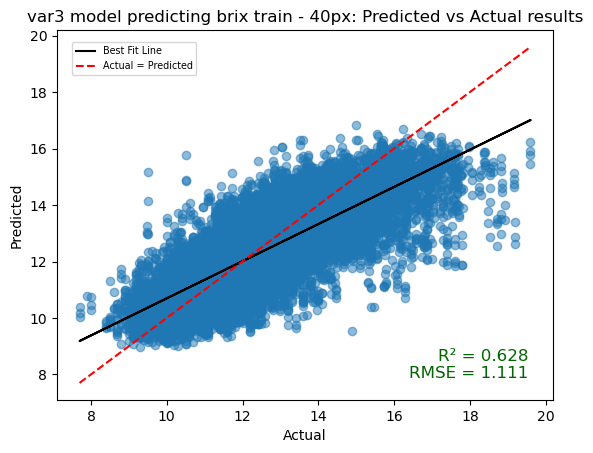

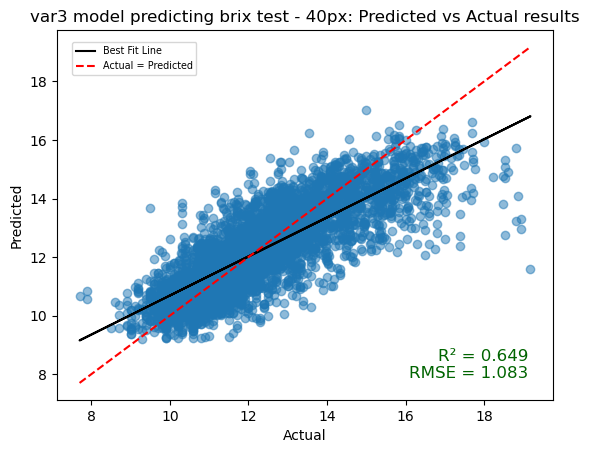

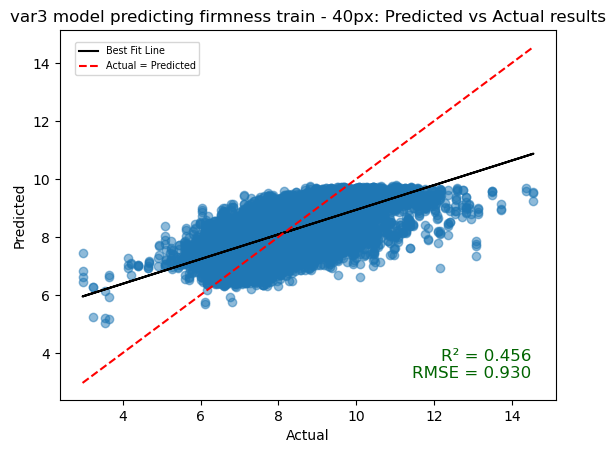

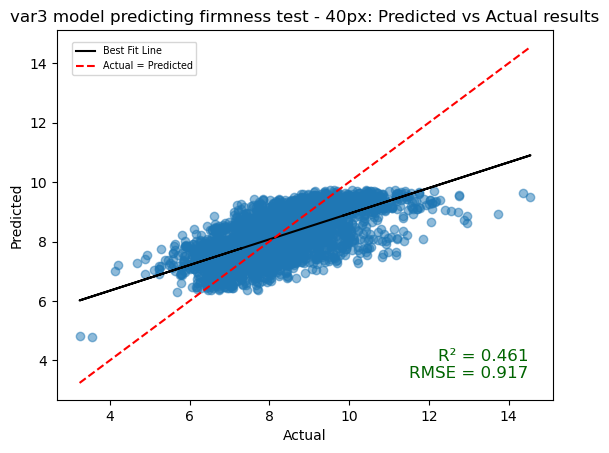

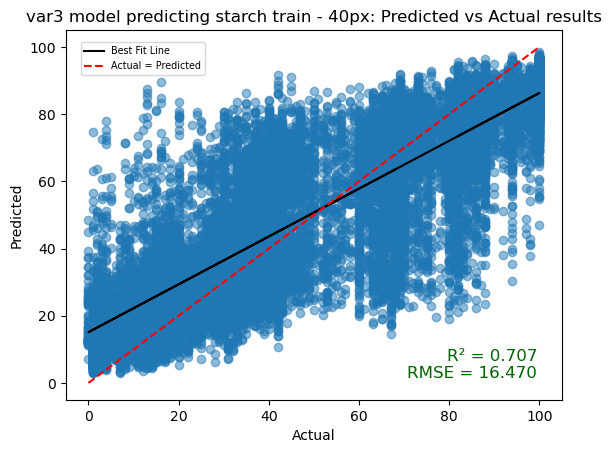

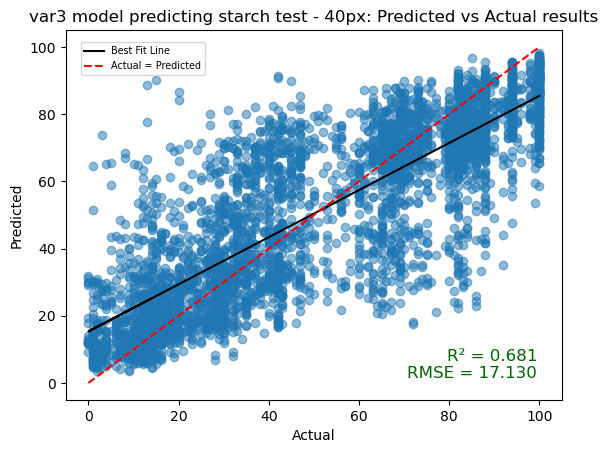

In [40]:
evaluation_plot(Actual_var3_train['Brix'], Predicted_var3_train['Brix'], 'var3 model predicting brix train', img_size)
evaluation_plot(Actual_var3['Brix'], Predicted_var3['Brix'], 'var3 model predicting brix test', img_size)

evaluation_plot(Actual_var3_train['Firmness'], Predicted_var3_train['Firmness'], 'var3 model predicting firmness train', img_size)
evaluation_plot(Actual_var3['Firmness'], Predicted_var3['Firmness'], 'var3 model predicting firmness test', img_size)

evaluation_plot(Actual_var3_train['Starch'], Predicted_var3_train['Starch'], 'var3 model predicting starch train', img_size)
evaluation_plot(Actual_var3['Starch'], Predicted_var3['Starch'], 'var3 model predicting starch test', img_size)

In [41]:
# MAE and MSE calculations
def calculate_metrics(y_true, y_pred):
    # 计算MSE
    mse = np.mean((y_true - y_pred) ** 2)
    # 计算RMSE
    rmse = np.sqrt(mse)
    # 计算MAE
    mae = np.mean(np.abs(y_true - y_pred))
    # 计算R²
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    return mse, rmse, mae, r2


In [43]:
print(calculate_metrics(Actual_var3_train['Brix'], Predicted_var3_train['Brix']))
print(calculate_metrics(Actual_var3_train['Firmness'], Predicted_var3_train['Firmness']))
print(calculate_metrics(Actual_var3_train['Starch'], Predicted_var3_train['Starch']))

(1.2344699618702817, 1.1110670375230658, 0.8356219779724132, 0.6284715665835447)
(0.8643706537652412, 0.9297153616915454, 0.7072297872092123, 0.4559559236547346)
(271.26190737897, 16.470030582211134, 12.387999039236316, 0.7069402864874665)


In [41]:
# print(Y_train_var3_train)

In [42]:
# # Data split by cultivar
# if img_size == 20 or img_size == 14:
#     training_data_save_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_Feb2025/'
# elif img_size == 50 or img_size == 40:  
#     training_data_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Training_data_50px/'
    
# # BB brix
# X_train_brix_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_train_all_years_Brix_shuffled.npy')
# Y_train_brix_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_validate_all_years_Brix_shuffled.npy')

# #FJ brix
# X_train_brix_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_train_all_years_Brix_shuffled.npy')
# Y_train_brix_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_validate_all_years_Brix_shuffled.npy')

# # GL brix
# X_train_brix_GL       = np.load(f'{training_data_path}all_years/Gala_X_train_all_years_Brix_shuffled.npy')
# Y_train_brix_GL       = np.load(f'{training_data_path}all_years/Gala_Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix_GL       = np.load(f'{training_data_path}all_years/Gala_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix_GL       = np.load(f'{training_data_path}all_years/Gala_Y_validate_all_years_Brix_shuffled.npy')

# #GD brix
# X_train_brix_GD       = np.load(f'{training_data_path}all_years/GD_X_train_all_years_Brix_shuffled.npy')
# Y_train_brix_GD       = np.load(f'{training_data_path}all_years/GD_Y_train_all_years_Brix_shuffled.npy')
# X_validate_brix_GD       = np.load(f'{training_data_path}all_years/GD_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_brix_GD       = np.load(f'{training_data_path}all_years/GD_Y_validate_all_years_Brix_shuffled.npy')


# # BB firmness
# X_train_firmness_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_train_all_years_Brix_shuffled.npy')
# Y_train_firmness_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_train_all_years_Brix_shuffled.npy')
# X_validate_firmness_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_firmness_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_validate_all_years_Brix_shuffled.npy')

# #FJ firmness
# X_train_firmness_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_train_all_years_Brix_shuffled.npy')
# Y_train_firmness_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_train_all_years_Brix_shuffled.npy')
# X_validate_firmness_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_firmness_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_validate_all_years_Brix_shuffled.npy')

# # GL firmness
# X_train_firmness_GL       = np.load(f'{training_data_path}all_years/Gala_X_train_all_years_Brix_shuffled.npy')
# Y_train_firmness_GL       = np.load(f'{training_data_path}all_years/Gala_Y_train_all_years_Brix_shuffled.npy')
# X_validate_firmness_GL       = np.load(f'{training_data_path}all_years/Gala_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_firmness_GL       = np.load(f'{training_data_path}all_years/Gala_Y_validate_all_years_Brix_shuffled.npy')

# #GD firmness
# X_train_firmness_GD       = np.load(f'{training_data_path}all_years/GD_X_train_all_years_Brix_shuffled.npy')
# Y_train_firmness_GD       = np.load(f'{training_data_path}all_years/GD_Y_train_all_years_Brix_shuffled.npy')
# X_validate_firmness_GD       = np.load(f'{training_data_path}all_years/GD_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_firmness_GD       = np.load(f'{training_data_path}all_years/GD_Y_validate_all_years_Brix_shuffled.npy')





# # BB starch
# X_train_starch_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_train_all_years_Brix_shuffled.npy')
# Y_train_starch_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_train_all_years_Brix_shuffled.npy')
# X_validate_starch_BB       = np.load(f'{training_data_path}all_years/Braeburn_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_starch_BB       = np.load(f'{training_data_path}all_years/Braeburn_Y_validate_all_years_Brix_shuffled.npy')

# #FJ starch
# X_train_starch_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_train_all_years_Brix_shuffled.npy')
# Y_train_starch_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_train_all_years_Brix_shuffled.npy')
# X_validate_starch_FJ       = np.load(f'{training_data_path}all_years/Fuji_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_starch_FJ       = np.load(f'{training_data_path}all_years/Fuji_Y_validate_all_years_Brix_shuffled.npy')

# # GL starch
# X_train_starch_GL       = np.load(f'{training_data_path}all_years/Gala_X_train_all_years_Brix_shuffled.npy')
# Y_train_starch_GL       = np.load(f'{training_data_path}all_years/Gala_Y_train_all_years_Brix_shuffled.npy')
# X_validate_starch_GL       = np.load(f'{training_data_path}all_years/Gala_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_starch_GL       = np.load(f'{training_data_path}all_years/Gala_Y_validate_all_years_Brix_shuffled.npy')

# #GD starch
# X_train_starch_GD       = np.load(f'{training_data_path}all_years/GD_X_train_all_years_Brix_shuffled.npy')
# Y_train_starch_GD       = np.load(f'{training_data_path}all_years/GD_Y_train_all_years_Brix_shuffled.npy')
# X_validate_starch_GD       = np.load(f'{training_data_path}all_years/GD_X_validate_all_years_Brix_shuffled.npy')
# Y_validate_starch_GD       = np.load(f'{training_data_path}all_years/GD_Y_validate_all_years_Brix_shuffled.npy')




In [43]:
# print(Y_train_Brix_train[:3])

In [44]:
# # Run for transformer models

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

# @keras.saving.register_keras_serializable()
# class PatchEmbedding(layers.Layer):
#     def __init__(self, embed_dim, num_patches, **kwargs):
#         super(PatchEmbedding, self).__init__(**kwargs)
#         self.embed_dim = embed_dim
#         self.num_patches = num_patches
#         self.projection = layers.Dense(embed_dim)
#         self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)

#     def call(self, x):
#         positions = tf.range(start=0, limit=self.num_patches, delta=1)
#         positions = tf.expand_dims(positions, axis=0)
#         embedded_patches = self.projection(x) + self.position_embedding(positions)
#         return embedded_patches

#     def get_config(self):
#         config = super().get_config()
#         config.update({
#             "embed_dim": self.embed_dim,
#             "num_patches": self.num_patches
#         })
#         return config

#     @classmethod
#     def from_config(cls, config):
#         # Ensure num_patches is provided, otherwise set a default value
#         return cls(
#             embed_dim=config.get("embed_dim", 64),  # Default to 64 if not provided
#             num_patches=config.get("num_patches", 100),  # Default to 100 if not provided
#         )


In [13]:
print(X_test_all_years_Starch_shuffled[:3])


['50px/UK2024/50px_Braeburn_943_15549.npy'
 '50px/UK2024/50px_Braeburn_1468_13456.npy'
 '50px/NZ2023/50px_Fuji_170_3467.npy']


In [13]:
spectral_path = '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/'

# The image paths (X-files) are exactly the same for each variable 
X_train_all_years_Starch_shuffled = [spectral_path + file for file in X_train_Starch_train]
# X_train_all_years_Brix_shuffled = [spectral_path + file for file in X_train_Brix_train]
# X_train_all_years_Firmness_shuffled = [spectral_path + file for file in X_train_Firmness_train]

X_test_all_years_Starch_shuffled = [spectral_path + file for file in X_test_all_years_Starch_shuffled]
# X_test_all_years_Brix_shuffled = [spectral_path + file for file in X_test_all_years_Brix_shuffled]
# X_test_all_years_Firmness_shuffled = [spectral_path + file for file in X_test_all_years_Firmness_shuffled]

print(X_train_all_years_Starch_shuffled[:3])
print(X_test_all_years_Starch_shuffled[:3])

['/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Braeburn_1453_7768.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Fuji_1423_11860.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2024/50px_Gala_125_9429.npy']
['/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/UK2024/50px_Braeburn_943_15549.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/UK2024/50px_Braeburn_1468_13456.npy', '/media/2tbdisk3/data/Haidee/May_2025_spectral_img/Spectral/50px/NZ2023/50px_Fuji_170_3467.npy']


In [15]:
print(len(X_train_all_years_Starch_shuffled))
print(len(X_test_all_years_Starch_shuffled))

17907
3934


<!-- ## Cycle through each X_test (this is each image) and get predictions ## -->

In [48]:
# print(X_test_all_years_Starch_shuffled[:2])
# print(X_test_all_years_Starch_encoder[:2])


In [49]:
# Running transformer model

# @tf.function
# def call(self, x):
#     positions = tf.range(start=0, limit=self.num_patches, delta=1)
#     positions = tf.expand_dims(positions, axis=0)
#     return self.projection(x) + self.position_embedding(positions)


In [50]:
# 

In [51]:
# # Convert data into model input format 20x20x210

# def prep_data(file_list, img_size, batch_size, prediction_model):
#     # missing_files = []  # List of missing files

#     # Initialize lists to store the batch data
#     batch_data = []
#     # batch_cultivars = []

#     prediction_model = prediction_model

#     # Load the batch of data from file paths
#     for i, file in enumerate(file_list):
#         try:
#             data = np.load(file)
#             batch_data.append(data)
#             # batch_cultivars.append(cultivars[i])
#         except FileNotFoundError:
#             # missing_files.append(file)
#             # print(f"File not found: {file}. Skipping...")
#             continue

#     # Convert lists to numpy arrays
#     batch_data = np.array(batch_data)  # Shape: (batch_size, img_size, img_size, 204)
#     # batch_cultivars = np.array(batch_cultivars)  # Shape: (batch_size, 6)
    

#         # Use the combined data for predictions
#     predictions = prediction_model.predict(batch_data)
#     # print(predictions)

#     return predictions
#     # else:
#     #     print("No data loaded.")
#     #     return None, missing_files


In [52]:
# Test if functions work
# test = prep_data(X_train_all_years_Starch_shuffled[:3], Firmness_encoder_shuffled[:3], img_size, batch_size, prediction_model_starch, hotencoding=False)
# print(test)

# def process_predictions(train_data, test_data, Y_train, Y_test, prediction_model, var='Brix'):

# Actual_starch_train, Predicted_Starch_train, Actual_Starch, Predicted_Starch = process_predictions(
#     train_predictions, test_predictions, Y_train_Starch_train[:3], Y_test_all_years_Starch_shuffled[:3], prediction_model_starch, var='Starch'
# )

# print(Predicted_Starch_train)

## Run predictions

In [ ]:
import gc
gc.collect()



1384

: 

In [ ]:
train_predictions = prep_data_generator(X_train_all_years_Starch_shuffled, Starch_encoder_shuffled, img_size, batch_size, hotencoding=True)
test_predictions = prep_data_generator(X_test_all_years_Starch_shuffled, X_test_all_years_Starch_encoder, img_size, batch_size, hotencoding=True)  

# # For 3D CNN
# train_generator = data_generator_3d(X_train_all_years_Starch_shuffled, Y_train_Starch_train, Starch_encoder_shuffled, batch_size, img_size=img_size, augment=True)
# test_predictions = prep_data_generator(X_test_all_years_Starch_shuffled, Y_test_all_years_Starch_shuffled, X_test_all_years_Starch_encoder, batch_size, img_size, augment = False)  


In [54]:
# Starch
# # Define your variables



# train_predictions = prep_data(X_train_all_years_Starch_shuffled, Firmness_encoder_shuffled, img_size, batch_size, prediction_model = prediction_model_starch)
# #no one hot encoding
# # train_predictions = prep_data(X_train_all_years_Starch_shuffled, img_size, batch_size, prediction_model = prediction_model_starch)
# train_predictions_df = pd.DataFrame(train_predictions, columns = ["Starch"])
# Actual_starch_train = pd.DataFrame(Y_train_Starch_train)
# Predicted_starch_train = train_predictions_df
# predictions_brix = prep_data(X_test_all_years_Starch_shuffled, X_test_all_years_Starch_encoder, img_size, batch_size, prediction_model = prediction_model_starch)
# #no one hot encoding
# # predictions_brix = prep_data(X_test_all_years_Starch_shuffled, img_size, batch_size, prediction_model = prediction_model_starch)
# image_predictions_df = pd.DataFrame(predictions_brix, columns = ["Starch"])
# # image_predictions_df.to_csv('image_prediction.csv')
# # Starch
# Actual_starch = pd.DataFrame(Y_test_all_years_Starch_shuffled)
# Predicted_starch = image_predictions_df

# Starch 
Actual_starch_train, Predicted_Starch_train, Actual_Starch, Predicted_Starch = process_predictions(
    train_predictions, test_predictions, Y_train_Starch_train, Y_test_all_years_Starch_shuffled, prediction_model_starch, var='Starch'
)

# print(Predicted_Starch_train)

560/560 [==============================] - 61s 108ms/step


2025-05-26 19:11:16.027743: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 5438843332857289490


123/123 [==============================] - 30s 247ms/step


In [67]:
print(Predicted_Starch_train[:5])

      Starch
0  18.291752
1  86.199959
2  29.684706
3  80.137688
4  76.029045


In [55]:
Actual_starch_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_starch_train.pkl')
Predicted_Starch_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Starch_train.pkl')
Actual_Starch.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_Starch.pkl')
Predicted_Starch.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Starch.pkl')


In [56]:
del prediction_model_starch

In [ ]:
# # Run 6, 7 and 8: 2025-03-04 Fuji 976 was a massive outlier 
#     # aggregated_Fuji_976_7551.npy
#     # aggregated_Fuji_976_7549.npy
#     # aggregated_Fuji_976_7550.npy
#     # aggregated_Fuji_976_7552.npy
#     # aggregated_Fuji_976_7553.npy
#     # aggregated_Fuji_976_7554.npy
# print(len(X_train_all_years_Starch_shuffled))
# indices = train_predictions_df[train_predictions_df['Starch']>150].index.tolist()
# print(indices)
# print([X_train_all_years_Starch_shuffled[i] for i in indices])


In [ ]:
# # # Remove outliers

 

# print(len(Predicted_starch_train))
# print(len(Actual_starch_train))

In [ ]:
# print(Outliers_test)

In [87]:
print(len(Actual_starch_train))
print(len(Predicted_Starch_train))

17907
17907


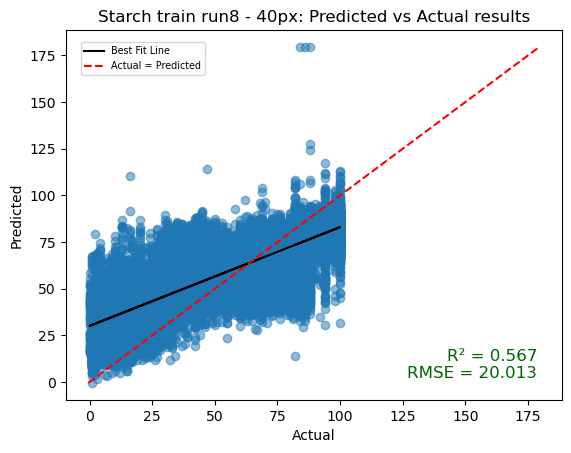

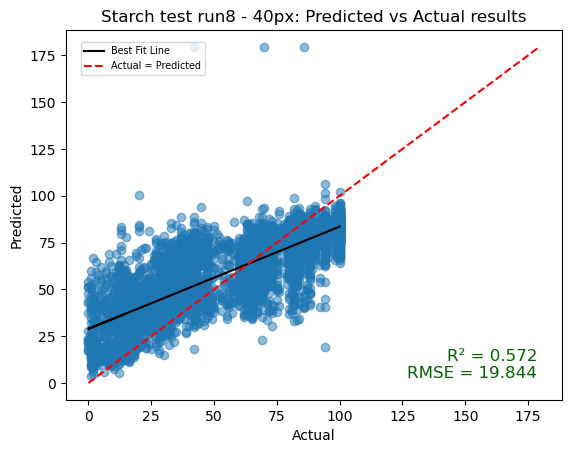

In [57]:
evaluation_plot(Actual_starch_train, Predicted_Starch_train, f'Starch train {run_no}', img_size)

evaluation_plot(Actual_Starch, Predicted_Starch, f'Starch test {run_no}',img_size)


In [58]:
# # # Define your variables



# # train_predictions = prep_data(X_train_all_years_Brix_shuffled, Brix_encoder_shuffled, img_size, batch_size, prediction_model = prediction_model_brix)

# # #no one hot encoding
# # # train_predictions = prep_data(X_train_all_years_Brix_shuffled, img_size, batch_size, prediction_model = prediction_model_brix)

# # train_predictions_df = pd.DataFrame(train_predictions, columns = ["Brix"])

# # Actual_brix_train = pd.DataFrame(Y_train_Brix_train)
# # Predicted_brix_train = train_predictions_df


# # predictions_brix = prep_data(X_test_all_years_Brix_shuffled, X_test_all_years_Brix_encoder, img_size, batch_size, prediction_model = prediction_model_brix)

# # #no one hot encoding
# # # predictions_brix = prep_data(X_test_all_years_Brix_shuffled, img_size, batch_size, prediction_model = prediction_model_brix)


# # image_predictions_df = pd.DataFrame(predictions_brix, columns = ["Brix"])

# # # image_predictions_df.to_csv('image_prediction.csv')

# # # Brix
# # Actual_brix = pd.DataFrame(Y_test_all_years_Brix_shuffled)
# # Predicted_brix = image_predictions_df

train_predictions = prep_data_generator(X_train_all_years_Starch_shuffled, Starch_encoder_shuffled, img_size, batch_size, hotencoding=True)
test_predictions = prep_data_generator(X_test_all_years_Starch_shuffled, X_test_all_years_Starch_encoder, img_size, batch_size, hotencoding=True)  

# Brix
Actual_brix_train, Predicted_Brix_train, Actual_Brix, Predicted_Brix = process_predictions(
    train_predictions, test_predictions, Y_train_Brix_train, Y_test_all_years_Brix_shuffled, prediction_model_brix, var = 'Brix'
)

     74/Unknown - 8s 106ms/step

560/560 [==============================] - 55s 98ms/step


2025-05-26 19:12:42.342599: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 14271216746369837247


123/123 [==============================] - 12s 100ms/step


2025-05-26 19:12:55.050311: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 14271216746369837247


In [59]:
del prediction_model_brix

In [60]:
Actual_brix_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_brix_train.pkl')
Predicted_Brix_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Brix_train.pkl')
Actual_Brix.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_Brix.pkl')
Predicted_Brix.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Brix.pkl')



In [61]:
import gc
gc.collect()

11096

In [ ]:
# # Run 6 & 7 & 9 & 10: 2025-03-04 Fuji 976 was a massive outlier 
#     # aggregated_Fuji_976_7551.npy
#     # aggregated_Fuji_976_7549.npy
#     # aggregated_Fuji_976_7550.npy
#     # aggregated_Fuji_976_7552.npy
#     # aggregated_Fuji_976_7553.npy
#     # aggregated_Fuji_976_7554.npy
# print(len(X_train_all_years_Brix_shuffled))
# indices = Predicted_brix_train[Predicted_brix_train['Brix']>=35].index.tolist()
# print(indices)
# print([X_train_all_years_Brix_shuffled[i] for i in indices])


In [ ]:
# # # Remove outliers


# # print(len(Predicted_brix_train))
# # print(len(Actual_brix_train))

# # Remove outliers from train_predictions_df and Actual_brix_train
# Predicted_brix_train = Predicted_brix_train[Predicted_brix_train['Brix'] <= 35]
# Actual_brix_train = Actual_brix_train.loc[Predicted_brix_train.index]



# # print(len(Predicted_brix_train))
# # print(len(Actual_brix_train))

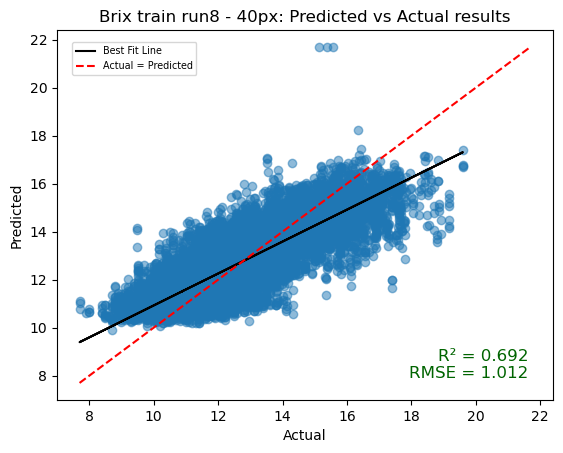

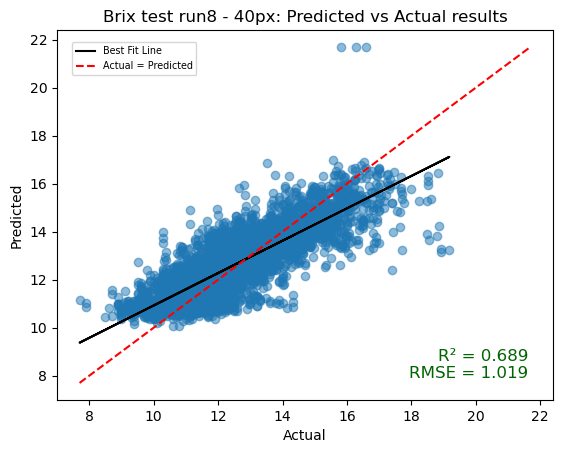

In [62]:

evaluation_plot(Actual_brix_train, Predicted_Brix_train, f'Brix train {run_no}', img_size)

evaluation_plot(Actual_Brix, Predicted_Brix, f'Brix test {run_no}', img_size)

In [63]:
# # Firmness
# # Define your variables



# # train_predictions = prep_data(X_train_all_years_Firmness_shuffled, Firmness_encoder_shuffled, img_size, batch_size, prediction_model = prediction_model_firmness)

# # #no one hot encoding
# # # train_predictions = prep_data(X_train_all_years_Firmness_shuffled, img_size, batch_size, prediction_model = prediction_model_firmness)

# # train_predictions_df = pd.DataFrame(train_predictions, columns = ["Firmness"])

# # Actual_firmness_train = pd.DataFrame(Y_train_Firmness_train)
# # Predicted_firmness_train = train_predictions_df


# # predictions_firmness = prep_data(X_test_all_years_Firmness_shuffled, X_test_all_years_Firmness_encoder, img_size, batch_size, prediction_model = prediction_model_firmness)

# # # no one hot encoding
# # # predictions_firmness = prep_data(X_test_all_years_Firmness_shuffled, img_size, batch_size, prediction_model = prediction_model_firmness)

# # image_predictions_df = pd.DataFrame(predictions_firmness, columns = ["Firmness"])

# # # image_predictions_df.to_csv('image_prediction.csv')

# # # Firmness
# # Actual_firmness = pd.DataFrame(Y_test_all_years_Firmness_shuffled)
# # Predicted_firmness = image_predictions_df

train_predictions = prep_data_generator(X_train_all_years_Starch_shuffled, Starch_encoder_shuffled, img_size, batch_size, hotencoding=True)
test_predictions = prep_data_generator(X_test_all_years_Starch_shuffled, X_test_all_years_Starch_encoder, img_size, batch_size, hotencoding=True)  

# Brix
Actual_firmness_train, Predicted_Firmness_train, Actual_Firmness, Predicted_Firmness = process_predictions(
    train_predictions, test_predictions, Y_train_Firmness_train, Y_test_all_years_Firmness_shuffled, prediction_model_firmness, var = 'Firmness'
)



      1/Unknown - 0s 184ms/step

560/560 [==============================] - 59s 106ms/step


2025-05-26 19:13:55.244226: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 5438843332857289490


123/123 [==============================] - 10s 84ms/step


In [ ]:
# # Run 6: 2025-03-04 Fuji 976 was a massive outlier and Jazz 399, 413, 406
#     # aggregated_Fuji_976_7551.npy
#     # aggregated_Fuji_976_7549.npy
#     # aggregated_Fuji_976_7550.npy
#     # aggregated_Fuji_976_7552.npy
#     # aggregated_Fuji_976_7553.npy
#     # aggregated_Fuji_976_7554.npy
# print(len(X_train_all_years_Firmness_shuffled))
# indices = train_predictions_df[train_predictions_df['Firmness'] < -2000].index.tolist()
# print(indices)
# print([X_train_all_years_Firmness_shuffled[i] for i in indices])


In [ ]:
# # Remove outliers


# print(len(train_predictions_df))
# print(len(Actual_firmness_train))

# # Remove outliers from train_predictions_df and Actual_firmness_train
# Predicted_firmness_train = train_predictions_df[train_predictions_df['Firmness'] < 40]
# Actual_firmness_train = Actual_firmness_train.loc[Predicted_firmness_train.index]



# print(len(Predicted_firmness_train))
# print(len(Actual_firmness_train))

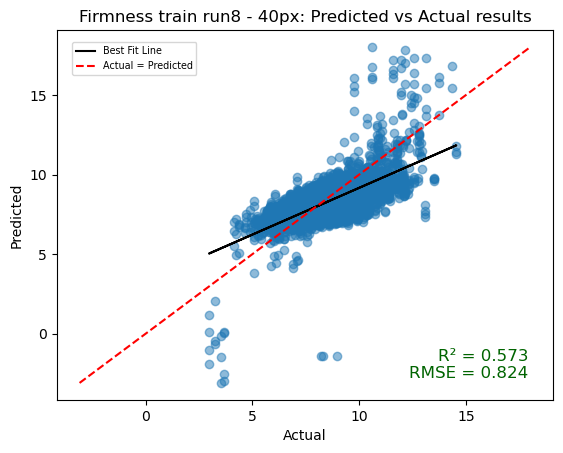

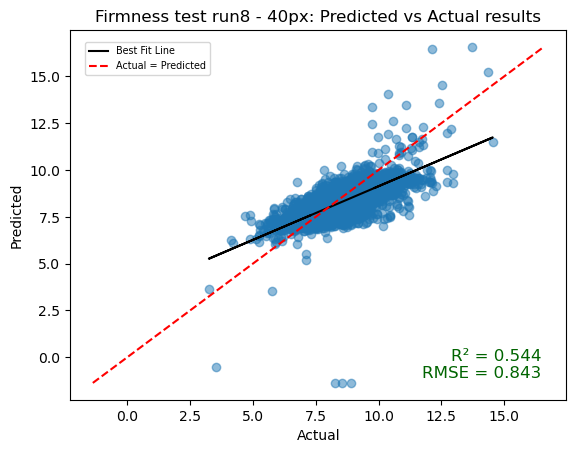

In [64]:
evaluation_plot(Actual_firmness_train, Predicted_Firmness_train, f'Firmness train {run_no}', img_size)

evaluation_plot(Actual_Firmness, Predicted_Firmness, f'Firmness test {run_no}', img_size)

In [65]:
Actual_firmness_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_firmness_train.pkl')
Predicted_Firmness_train.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Firmness_train.pkl')
Actual_Firmness.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Actual_Firmness.pkl')
Predicted_Firmness.to_pickle(f'{prediction_save_path}{run_no}/{run_no}_Predicted_Firmness.pkl')


In [66]:
del prediction_model_firmness

<!-- ## View of model architecture -->

In [ ]:
import gc
gc.collect()

11168

: 

In [ ]:
# # Try to load the model architecture from model
# import tensorflow as tf
# import keras
# from tensorflow.keras.utils import plot_model


# from tensorflow.keras.models import load_model
# File_path = '/media/2tbdisk1/data/Haidee/Training_results/Feb2025/all_years_results/'
# model = tf.keras.models.load_model(f"{File_path}2025-02-21run1_2025-02-21_model_file_brix.keras")

# model_complex_starch_only = tf.keras.models.clone_model(model)
# # model_complex_starch_only.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])
# model_complex_starch_only.summary()

# # Visualize the model architecture
# plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

In [ ]:
# 

In [1]:
import pickle
import pandas as pd

path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Bayesian_optimisation_files/'

brix_opt = pd.read_pickle(f'{path}bayesian_optimization_results_brix_ViT.pkl')
firmness_opt = pd.read_pickle(f'{path}bayesian_optimization_results_firmness_ViT.pkl')
starch_opt = pd.read_pickle(f'{path}bayesian_optimization_results_starch_ViT.pkl')

In [7]:
print(brix_opt[brix_opt.val_loss == brix_opt.val_loss.min()])
print(firmness_opt[firmness_opt.val_loss == firmness_opt.val_loss.min()])
print(starch_opt[starch_opt.val_loss == starch_opt.val_loss.min()])

    patch_size  projection_dim  transformer_layers  num_heads mlp_head_units  \
25           8             256                   5          3        256-128   

    dropout_rate  val_loss  
25           0.1  0.725627  
    patch_size  projection_dim  transformer_layers  num_heads mlp_head_units  \
39          10              64                   3          5         128-64   

    dropout_rate  val_loss  
39      0.223294  0.549537  
   patch_size  projection_dim  transformer_layers  num_heads mlp_head_units  \
4           9              66                   4          4     256-128-64   

   dropout_rate    val_loss  
4      0.137285  282.144531  
